In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv('Housing_cleaned.csv')

In [3]:
df.head()

,area,bedrooms,bathrooms,stories,parking,furnishingstatus,logprice,mainroadbin,guest_room,nbasement,hot_waterheating,air_conditioning,pref_area
0,7420,4,2,3,2,2,16.403275,1,0,0,0,1,1
1,8960,4,4,4,3,2,16.321036,1,0,0,0,1,0
2,9960,3,2,2,2,1,16.321036,1,0,1,0,0,1
3,7500,4,2,2,3,2,16.318175,1,0,1,0,1,1
4,7420,4,1,2,2,2,16.250001,1,1,1,0,1,0


In [4]:
df.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'furnishingstatus', 'logprice', 'mainroadbin', 'guest_room',
       'nbasement', 'hot_waterheating', 'air_conditioning', 'pref_area'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area              545 non-null    int64  
 1   bedrooms          545 non-null    int64  
 2   bathrooms         545 non-null    int64  
 3   stories           545 non-null    int64  
 4   parking           545 non-null    int64  
 5   furnishingstatus  545 non-null    int64  
 6   logprice          545 non-null    float64
 7   mainroadbin       545 non-null    int64  
 8   guest_room        545 non-null    int64  
 9   nbasement         545 non-null    int64  
 10  hot_waterheating  545 non-null    int64  
 11  air_conditioning  545 non-null    int64  
 12  pref_area         545 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 55.5 KB


In [6]:
df.head()

,area,bedrooms,bathrooms,stories,parking,furnishingstatus,logprice,mainroadbin,guest_room,nbasement,hot_waterheating,air_conditioning,pref_area
0,7420,4,2,3,2,2,16.403275,1,0,0,0,1,1
1,8960,4,4,4,3,2,16.321036,1,0,0,0,1,0
2,9960,3,2,2,2,1,16.321036,1,0,1,0,0,1
3,7500,4,2,2,3,2,16.318175,1,0,1,0,1,1
4,7420,4,1,2,2,2,16.250001,1,1,1,0,1,0


In [7]:
df['logprice'].value_counts()

logprice
15.250595    17
15.068274    17
15.404746    12
15.473739     9
15.538277     9
             ..
14.573977     1
14.488455     1
14.433395     1
14.414347     1
14.384879     1
Name: count, Length: 219, dtype: int64

In [8]:
df.tail()

,area,bedrooms,bathrooms,stories,parking,furnishingstatus,logprice,mainroadbin,guest_room,nbasement,hot_waterheating,air_conditioning,pref_area
540,3000,2,1,1,2,0,14.414347,1,0,1,0,0,0
541,2400,3,1,1,0,1,14.384879,0,0,0,0,0,0
542,3620,2,1,1,0,0,14.375126,1,0,0,0,0,0
543,2910,3,1,1,0,2,14.375126,0,0,0,0,0,0
544,3850,3,1,2,0,0,14.375126,1,0,0,0,0,0


In [9]:
#independent and dependent features
X=df.drop('logprice',axis=1)
y=df['logprice']

In [10]:
X.head()

,area,bedrooms,bathrooms,stories,parking,furnishingstatus,mainroadbin,guest_room,nbasement,hot_waterheating,air_conditioning,pref_area
0,7420,4,2,3,2,2,1,0,0,0,1,1
1,8960,4,4,4,3,2,1,0,0,0,1,0
2,9960,3,2,2,2,1,1,0,1,0,0,1
3,7500,4,2,2,3,2,1,0,1,0,1,1
4,7420,4,1,2,2,2,1,1,1,0,1,0


In [11]:
y

0      16.403275
1      16.321036
2      16.321036
3      16.318175
4      16.250001
         ...    
540    14.414347
541    14.384879
542    14.375126
543    14.375126
544    14.375126
Name: logprice, Length: 545, dtype: float64

In [12]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [13]:
X_train.shape,X_test.shape

((408, 12), (137, 12))

In [14]:
## Feature Selection based on correlaltion
X_train.corr()

,area,bedrooms,bathrooms,stories,parking,furnishingstatus,mainroadbin,guest_room,nbasement,hot_waterheating,air_conditioning,pref_area
area,1.000000,0.147704,0.178448,0.074478,0.318294,0.132204,0.294848,0.167665,0.042414,-0.000499,0.223670,0.200870
bedrooms,0.147704,1.000000,0.390371,0.418396,0.145792,0.116839,-0.001831,0.082471,0.098824,0.026556,0.215004,0.058994
bathrooms,0.178448,0.390371,1.000000,0.321693,0.174586,0.120390,0.029114,0.078663,0.082249,0.039210,0.210457,-0.002169
stories,0.074478,0.418396,0.321693,1.000000,0.059443,0.128422,0.101325,0.057636,-0.190648,0.029339,0.332004,-0.008989
parking,0.318294,0.145792,0.174586,0.059443,1.000000,0.146657,0.184304,0.008764,0.020675,0.083586,0.184398,0.090725
furnishingstatus,0.132204,0.116839,0.120390,0.128422,0.146657,1.000000,0.153595,0.125810,0.147311,0.046012,0.159616,0.107805
mainroadbin,0.294848,-0.001831,0.029114,0.101325,0.184304,0.153595,1.000000,0.097350,0.047126,-0.008409,0.114316,0.224262
guest_room,0.167665,0.082471,0.078663,0.057636,0.008764,0.125810,0.097350,1.000000,0.395121,-0.049133,0.159273,0.177526
nbasement,0.042414,0.098824,0.082249,-0.190648,0.020675,0.147311,0.047126,0.395121,1.000000,-0.028514,0.090885,0.223370
hot_waterheating,-0.000499,0.026556,0.039210,0.029339,0.083586,0.046012,-0.008409,-0.049133,-0.028514,1.000000,-0.128115,-0.047935


<Axes: >

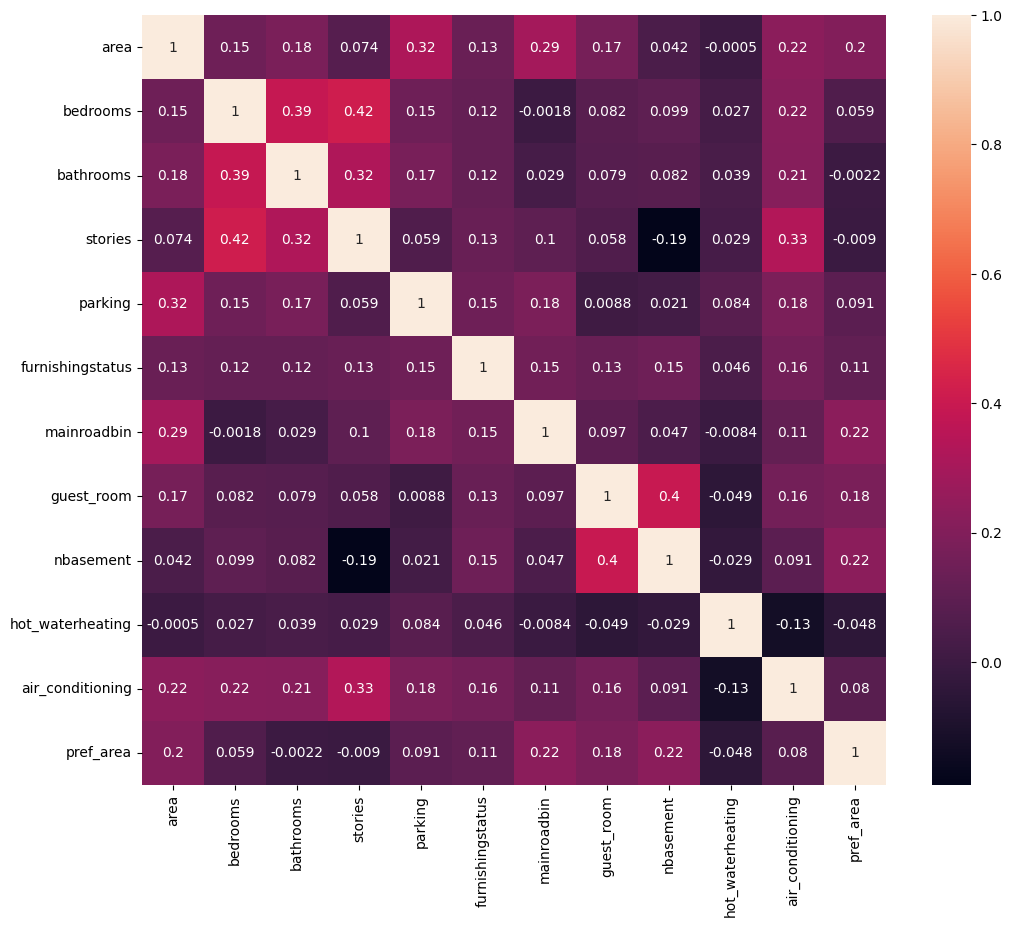

In [15]:
## Check for multicollinearity
plt.figure(figsize=(12,10))
corr=X_train.corr()
sns.heatmap(corr,annot=True)


In [16]:
X_train.corr()

,area,bedrooms,bathrooms,stories,parking,furnishingstatus,mainroadbin,guest_room,nbasement,hot_waterheating,air_conditioning,pref_area
area,1.000000,0.147704,0.178448,0.074478,0.318294,0.132204,0.294848,0.167665,0.042414,-0.000499,0.223670,0.200870
bedrooms,0.147704,1.000000,0.390371,0.418396,0.145792,0.116839,-0.001831,0.082471,0.098824,0.026556,0.215004,0.058994
bathrooms,0.178448,0.390371,1.000000,0.321693,0.174586,0.120390,0.029114,0.078663,0.082249,0.039210,0.210457,-0.002169
stories,0.074478,0.418396,0.321693,1.000000,0.059443,0.128422,0.101325,0.057636,-0.190648,0.029339,0.332004,-0.008989
parking,0.318294,0.145792,0.174586,0.059443,1.000000,0.146657,0.184304,0.008764,0.020675,0.083586,0.184398,0.090725
furnishingstatus,0.132204,0.116839,0.120390,0.128422,0.146657,1.000000,0.153595,0.125810,0.147311,0.046012,0.159616,0.107805
mainroadbin,0.294848,-0.001831,0.029114,0.101325,0.184304,0.153595,1.000000,0.097350,0.047126,-0.008409,0.114316,0.224262
guest_room,0.167665,0.082471,0.078663,0.057636,0.008764,0.125810,0.097350,1.000000,0.395121,-0.049133,0.159273,0.177526
nbasement,0.042414,0.098824,0.082249,-0.190648,0.020675,0.147311,0.047126,0.395121,1.000000,-0.028514,0.090885,0.223370
hot_waterheating,-0.000499,0.026556,0.039210,0.029339,0.083586,0.046012,-0.008409,-0.049133,-0.028514,1.000000,-0.128115,-0.047935


In [17]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: 
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [18]:
corr_features=correlation(X_train,0.5)

In [19]:
corr_features

set()

In [20]:
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape,X_test.shape

((408, 12), (137, 12))

Standardization

In [21]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [22]:
X_train_scaled

array([[-0.24934679, -1.25962345,  1.5277588 , ..., -0.2270383 ,
         1.48748056, -0.56225353],
       [ 0.22262697, -1.25962345, -0.55694217, ..., -0.2270383 ,
        -0.67227769, -0.56225353],
       [-0.73947339,  0.0514132 , -0.55694217, ..., -0.2270383 ,
        -0.67227769,  1.77855709],
       ...,
       [-0.29472888,  0.0514132 ,  1.5277588 , ...,  4.40454311,
        -0.67227769, -0.56225353],
       [-0.50348651, -1.25962345, -0.55694217, ..., -0.2270383 ,
        -0.67227769, -0.56225353],
       [ 0.15909204,  0.0514132 ,  1.5277588 , ..., -0.2270383 ,
         1.48748056, -0.56225353]], shape=(408, 12))

Text(0.5, 1.0, 'X_train After Scaling')

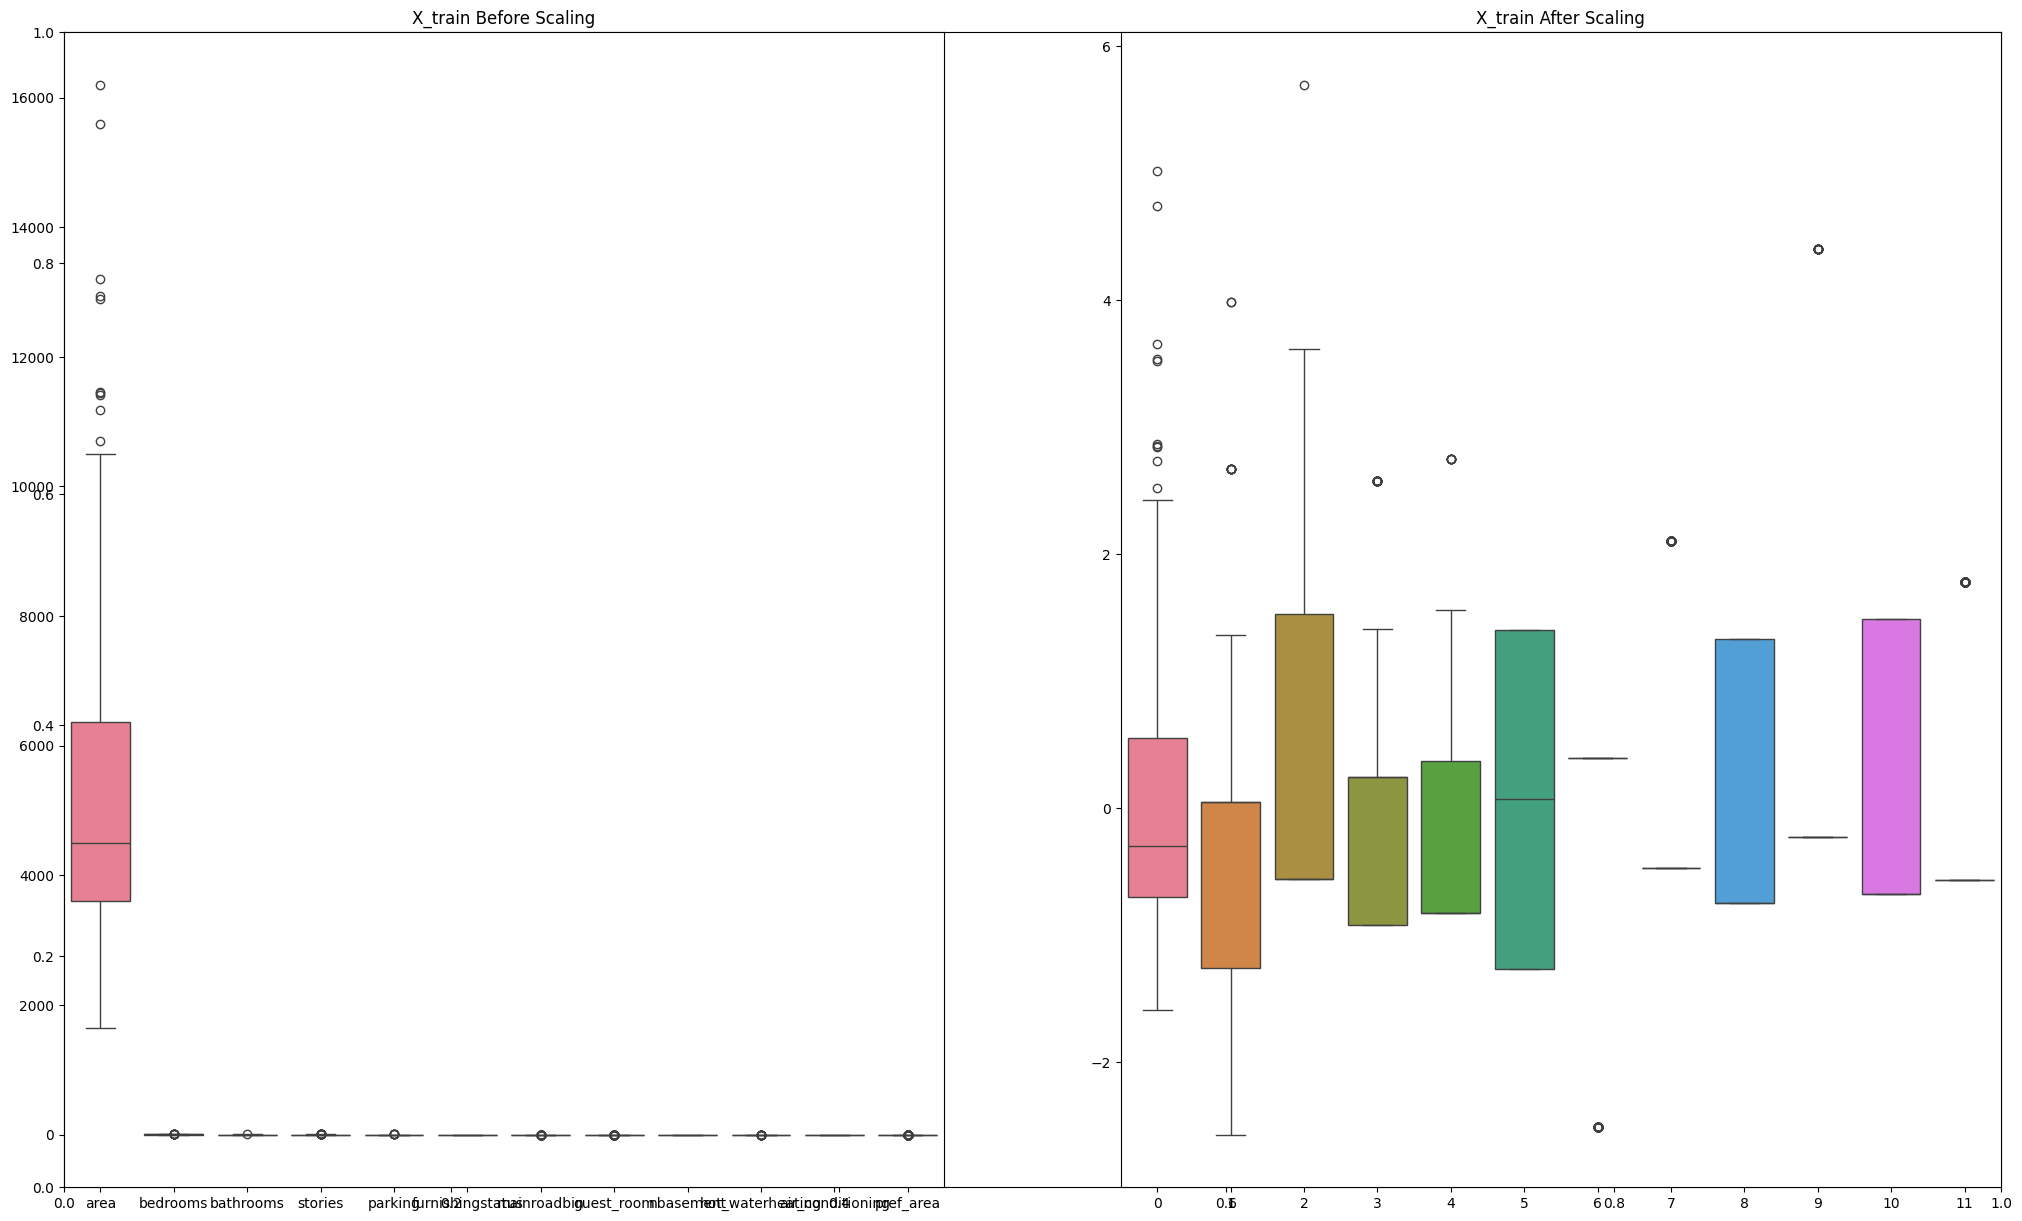

In [23]:
plt.subplots(figsize=(25, 15))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')

## Linear Regression Model

Mean absolute error 0.19559276674006784
R2 Score 0.6613596678111577


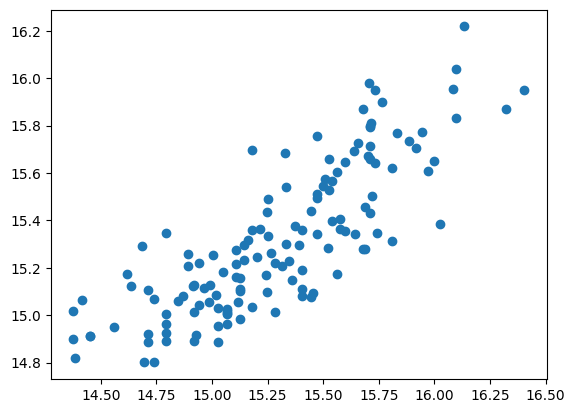

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred=linreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

## Lasso Regression

Mean absolute error 0.3576475481499466
R2 Score -0.0017370691371731972


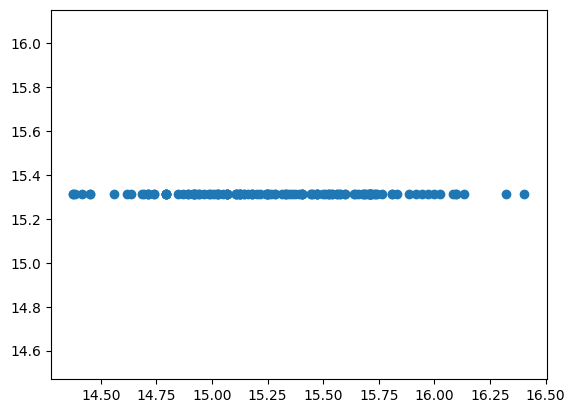

In [25]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

### Cross Validation Lasso

In [26]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


Mean absolute error 0.1956216788590279
R2 Score 0.6610921775321272


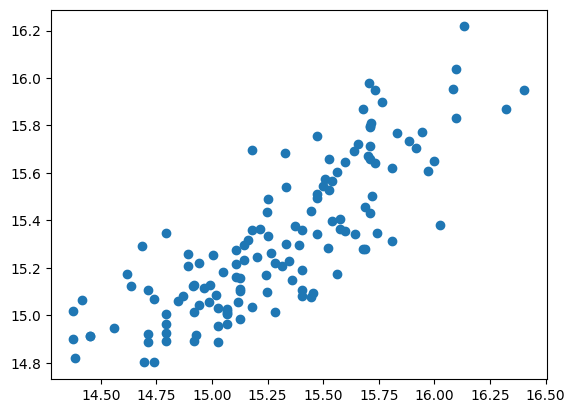

In [27]:
y_pred=lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

## Ridge Regression model

Mean absolute error 0.1955701368852574
R2 Score 0.6612595195858774


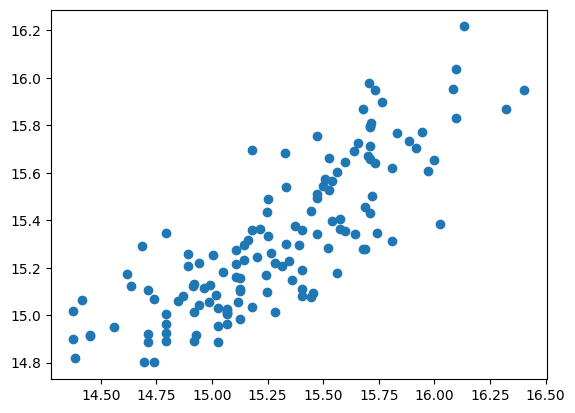

In [28]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

Mean absolute error 0.19543746955039212
R2 Score 0.6602617324956411


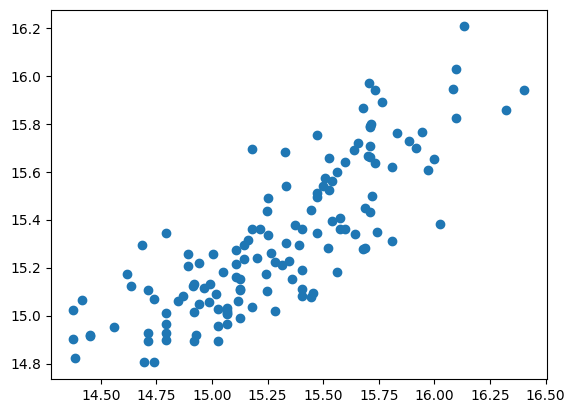

In [29]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred=ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

In [30]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

## Elasticnet Regression

Mean absolute error 0.3576475481499466
R2 Score -0.0017370691371731972


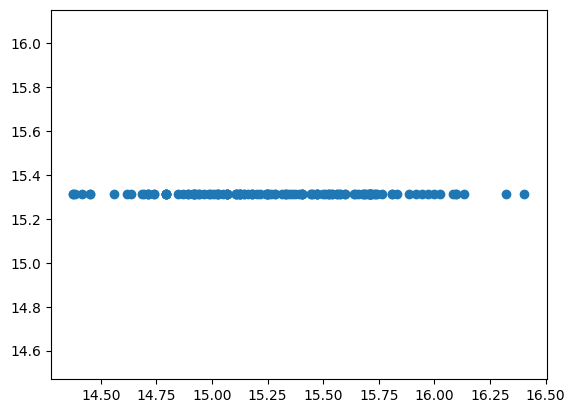

In [31]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

Mean absolute error 0.19564364335178674
R2 Score 0.6608416063076925


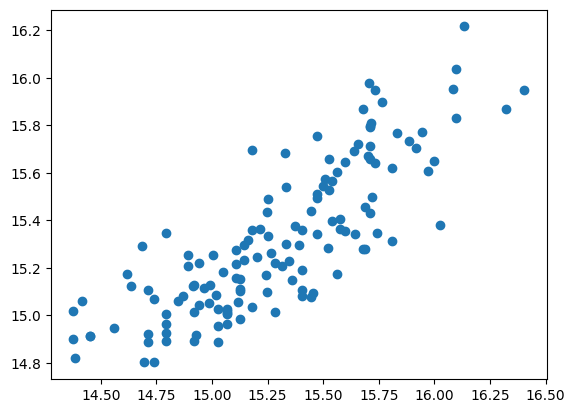

In [32]:
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(X_train_scaled,y_train)
y_pred=elasticcv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

In [33]:
elasticcv.alphas_

array([0.38035937, 0.35472442, 0.33081718, 0.30852121, 0.28772791,
       0.26833601, 0.25025107, 0.23338498, 0.21765561, 0.20298635,
       0.18930575, 0.17654718, 0.16464849, 0.15355173, 0.14320286,
       0.13355147, 0.12455054, 0.11615625, 0.10832771, 0.10102679,
       0.09421792, 0.08786795, 0.08194594, 0.07642306, 0.0712724 ,
       0.06646888, 0.0619891 , 0.05781124, 0.05391496, 0.05028127,
       0.04689248, 0.04373208, 0.04078469, 0.03803594, 0.03547244,
       0.03308172, 0.03085212, 0.02877279, 0.0268336 , 0.02502511,
       0.0233385 , 0.02176556, 0.02029864, 0.01893058, 0.01765472,
       0.01646485, 0.01535517, 0.01432029, 0.01335515, 0.01245505,
       0.01161563, 0.01083277, 0.01010268, 0.00942179, 0.00878679,
       0.00819459, 0.00764231, 0.00712724, 0.00664689, 0.00619891,
       0.00578112, 0.0053915 , 0.00502813, 0.00468925, 0.00437321,
       0.00407847, 0.00380359, 0.00354724, 0.00330817, 0.00308521,
       0.00287728, 0.00268336, 0.00250251, 0.00233385, 0.00217

In [34]:
import pickle
pickle.dump(ridgecv,open('model.pkl','wb'))
pickle.dump(scaler,open('scaler.pkl','wb'))